In [12]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import torch.nn.functional as F

from model.loss_function.siamese.custom_siamese_loss import CustomSiameseLoss
from model.architecture.siamese_residual_block import ResidualSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from model.trainers.siamese_trainer import SiameseTrainer
from utils.io_utils import *
from analytic_methods.EVM_method import EVM
from visualization.results.metrics_visualizator import MetricsVisualizator
from visualization.data.weights_visualizator import WeightsVisualizator
from metrics.evaluator import Evaluator
from model.loss_function.siamese.COP_optimized_siamese_loss import COPOptimizedSiameseLoss

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cuda
GPU: NVIDIA GeForce RTX 2060


In [30]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4, 0.45, 0.5]
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

BATCH_SIZE = 1024
LEARNING_RATE = 5e-4
NN_weights_predictions = {}

In [10]:
def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


def compare_results_dict(solver, evaluator, matrices: dict, weights: dict, predicted_priority_weights: dict):
    cr_values = np.array(sorted(list(matrices.keys())))

    all_mae_evm = []
    all_kendall_taus_evm = []

    for cr in cr_values:
        test_matrices = matrices[cr]
        weights_vectors = weights[cr]
        
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        
        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)

    mae_errors_nn_list = []
    kendall_taus_nn_list = []
    nn_names_list = []

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(cr_values)} consistency rates.")
    print(f"Global mean CR: {np.mean(cr_values):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}")
    print("-" * 40)

    for nn_name, pred_cr_dict in predicted_priority_weights.items():
        nn_names_list.append(nn_name)
        all_mae_nn = []
        all_kendall_taus_nn = []

        for cr in cr_values:
            weights_vectors = weights[cr]
            pred_weights_vectors = pred_cr_dict[cr]

            mae_nn, kendall_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)
            
            all_mae_nn.append(np.mean(mae_nn))
            all_kendall_taus_nn.append(np.mean(kendall_taus_nn))

        final_mae_nn = np.array(all_mae_nn)
        final_kendall_taus_nn = np.array(all_kendall_taus_nn)

        mae_errors_nn_list.append(final_mae_nn)
        kendall_taus_nn_list.append(final_kendall_taus_nn)

        print(f"Network: {nn_name}")
        print(f"  -> Global mean MAE: {np.mean(final_mae_nn):.4f}")
        print(f"  -> Global mean Kendall correlation: {np.mean(final_kendall_taus_nn):.4f}")
        print("-" * 40)

    viz = MetricsVisualizator()
    viz.plot_comparison_lists(
        cr_values=cr_values,
        mae_errors_analytic=final_mae_evm,
        kendall_taus_analytic=final_kendall_taus_evm,
        mae_errors_nn=mae_errors_nn_list,
        kendall_taus_nn=kendall_taus_nn_list,
        nn_name=nn_names_list
    )


def predict_batch_weights_siamese(model: torch.nn.Module, matrices: np.ndarray, device: torch.device) -> np.ndarray:
    model = model.to(device)
    model.eval()

    tensor_matrices = torch.tensor(matrices, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrices + 1e-8)
    tensor_input = tensor_log.unsqueeze(1)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights_batch = weights.cpu().numpy()
    return final_weights_batch


## Searching for best loss weights

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5
COP = 1
REC = 0.5
STAB = 0.2
CONS = 2

MODEL_TYPE = "siamese"
LOSS_PARAM = f"cop{int(COP*100)}_rec{int(REC*100)}_stab{int(STAB*100)}_cons{int(CONS*100)}"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"


model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0655
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6182


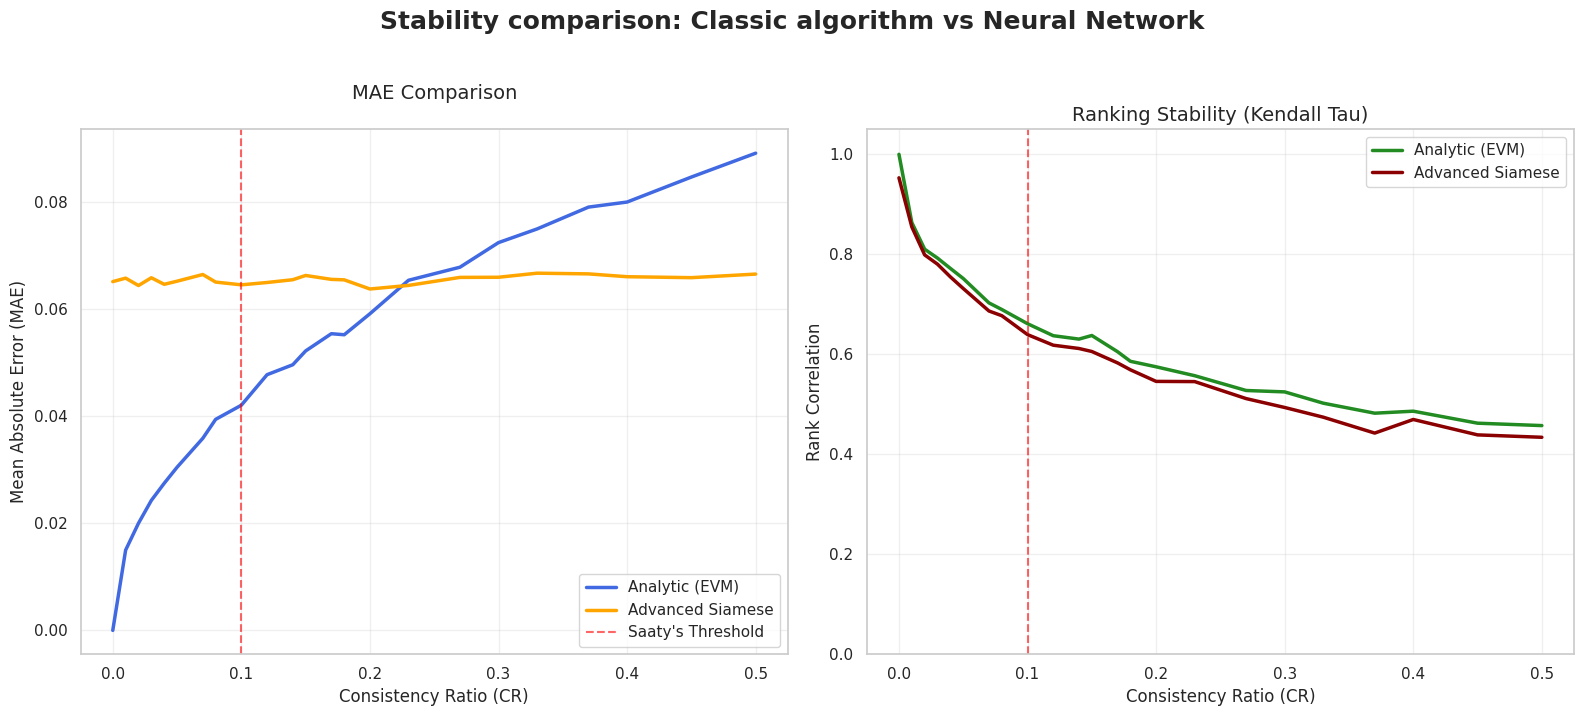

In [18]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5
COP = 2
REC = 3
STAB = 0.1
CONS = 0.5

MODEL_TYPE = "siamese"
LOSS_PARAM = f"cop{int(COP*100)}_rec{int(REC*100)}_stab{int(STAB*100)}_cons{int(CONS*100)}"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"


model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0476
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6222


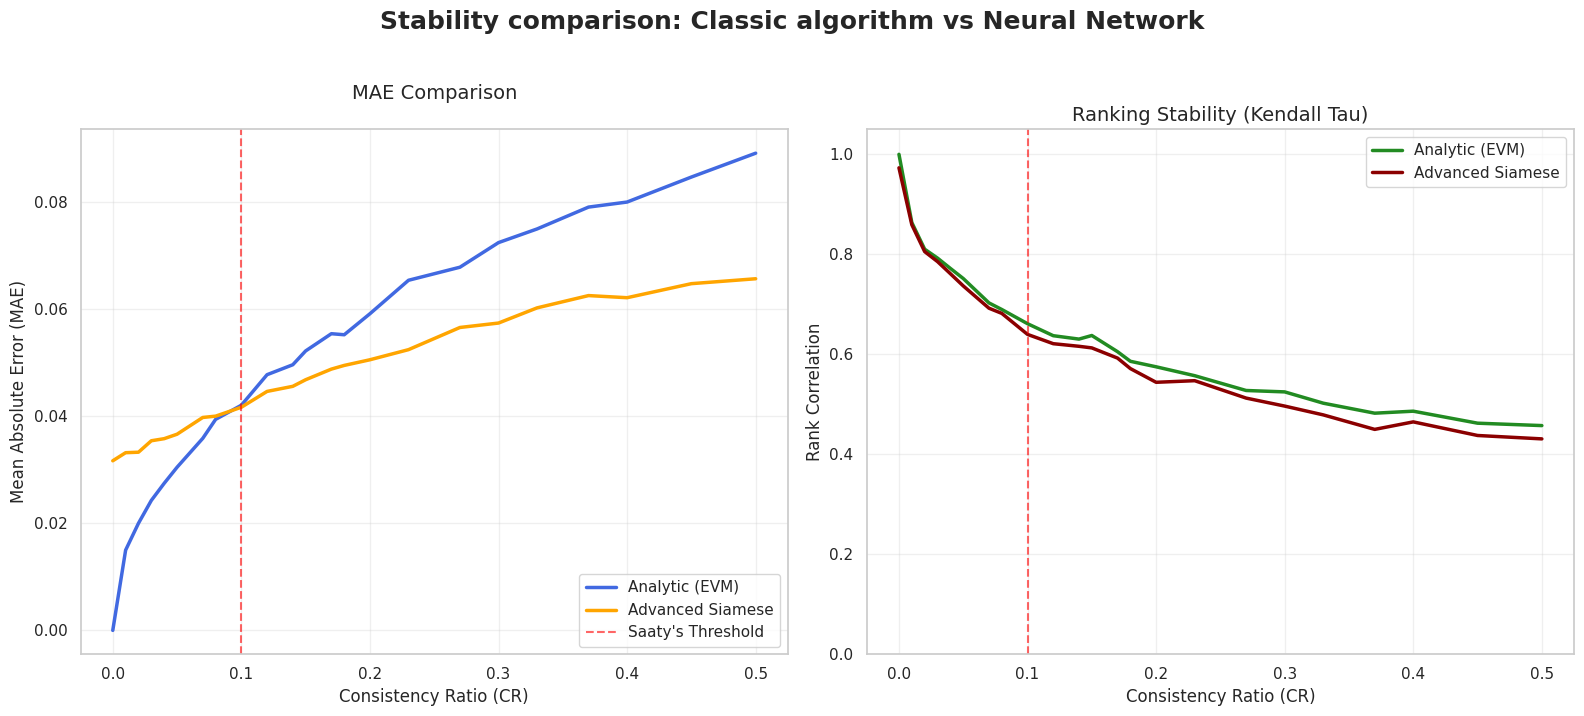

In [38]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

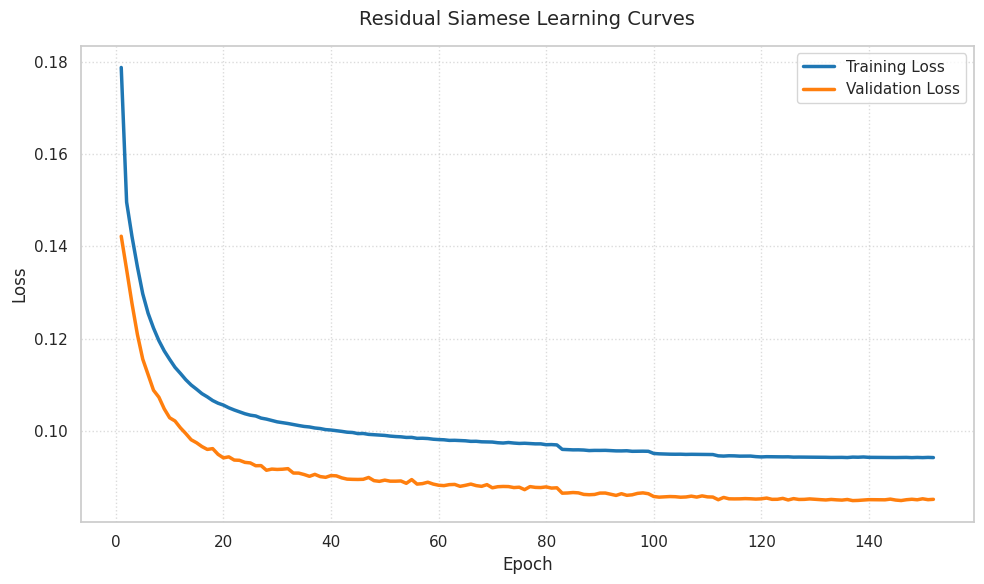

In [40]:
metrics_viz = MetricsVisualizator()
metrics_viz.display_loss(history, "Residual Siamese")

In [33]:
NN_weights_predictions["Siamese, Matrices COP"] = predicted_priority_weights

### Wnioski - dopasowanie wag funkcji straty

Analiza wariantów hiperparametrów funkcji straty ujawnia kluczowy wpływ balansu między rekonstrukcją a wymuszaniem spójności na zachowanie modelu. Porównanie obu eksperymentów pozwala na sformułowanie następujących wniosków inżynierskich:

#### 1. Dominacja spójności nad precyzją
**Wagi:** `COP = 1`, `REC = 0.5`, `STAB = 0.2`, `CONS = 2`

* **Zjawisko wypłaszczenia błędu:** Na pierwszym wykresie widać, że błąd MAE jest całkowicie płaski i oscyluje wokół wartości $0.065$, niezależnie od poziomu szumu. 
* **Przyczyna:** Zbyt wysoka waga dla kary za brak spójności reprezentacji (`CONS = 2`) przy jednoczesnym zignorowaniu odtwarzania wartości wektora bazowego (`REC = 0.5`) sprawiła, że sieć całkowicie zignorowała poprawne wartości priorytetów. Zamiast tego zoptymalizowała się do najprostszego rozwiązania: zaczęła zwracać stały, uśredniony wektor dla każdej macierzy, co zrównało błąd dla macierzy idealnych i skrajnie zaszumionych.

#### 2. Dopasowanie wag
**Wagi:** `COP = 2`, `REC = 3`, `STAB = 0.1`, `CONS = 0.5`

* **Odzyskanie dynamiki błędu:** Drastyczne zwiększenie wagi dla błędu odtwarzania (`REC = 3`) oraz zmniejszenie wymogu spójności (`CONS = 0.5`) odmroziło sieć. Błąd MAE zaczyna się teraz od znacznie niższego pułapu (ok. $0.03$) dla macierzy idealnych i rośnie wraz z zaszumieniem.
* **Wcześniejszy punkt przecięcia z EVM:** Dzięki silniejszemu skupieniu na rekonstrukcji wektorów oraz kontrastowaniu, sieć szybciej zaczyna wygrywać z klasycznym algorytmem EVM. Krzywa MAE sieci przecina krzywą EVM już w okolicach progu Saaty'ego ($CR \approx 0.1$), co oznacza, że dla macierzy choćby lekko zaszumionych sieć zaczyna dostarczać precyzyjniejsze wagi niż metoda analityczna.

#### 3. Wnioski ogólne i sztywność topologiczna rankingu
Niezależnie od drastycznych zmian w optymalizacji wag funkcji straty (MAE reaguje na nie bardzo silnie), **jakość samego rankingu pozostaje w zasadzie niewzruszona**.

**Inwariantność Kendall Tau:** Na prawych wykresach w obu wariantach eksperymentu krzywa stabilności rankingu wygląda niemal identycznie. Sieć wciąż podąża dokładnie śladem algorytmu EVM. Optymalizacja wag funkcji straty pozwala sieci lepiej estymować *ciągłe wartości* wektorów priorytetów, ale **nie zmienia samej logiki porządkowania alternatyw**. Sieć syjamska nie potrafi wyabstrahować lepszej heurystyki rankingowej niż klasyczny algorytm wektorów własnych – jest w stanie jedynie łagodzić ekstremalne odchylenia numeryczne w jego wynikach.

## Optimizing loss function parts

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5
COP = 0.2
REC = 10
STAB = 2.5
CONS = 4

MODEL_TYPE = "siamese"
LOSS_PARAM = f"cop{int(COP*100)}_rec{int(REC*100)}_stab{int(STAB*100)}_cons{int(CONS*100)}"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0629
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6425


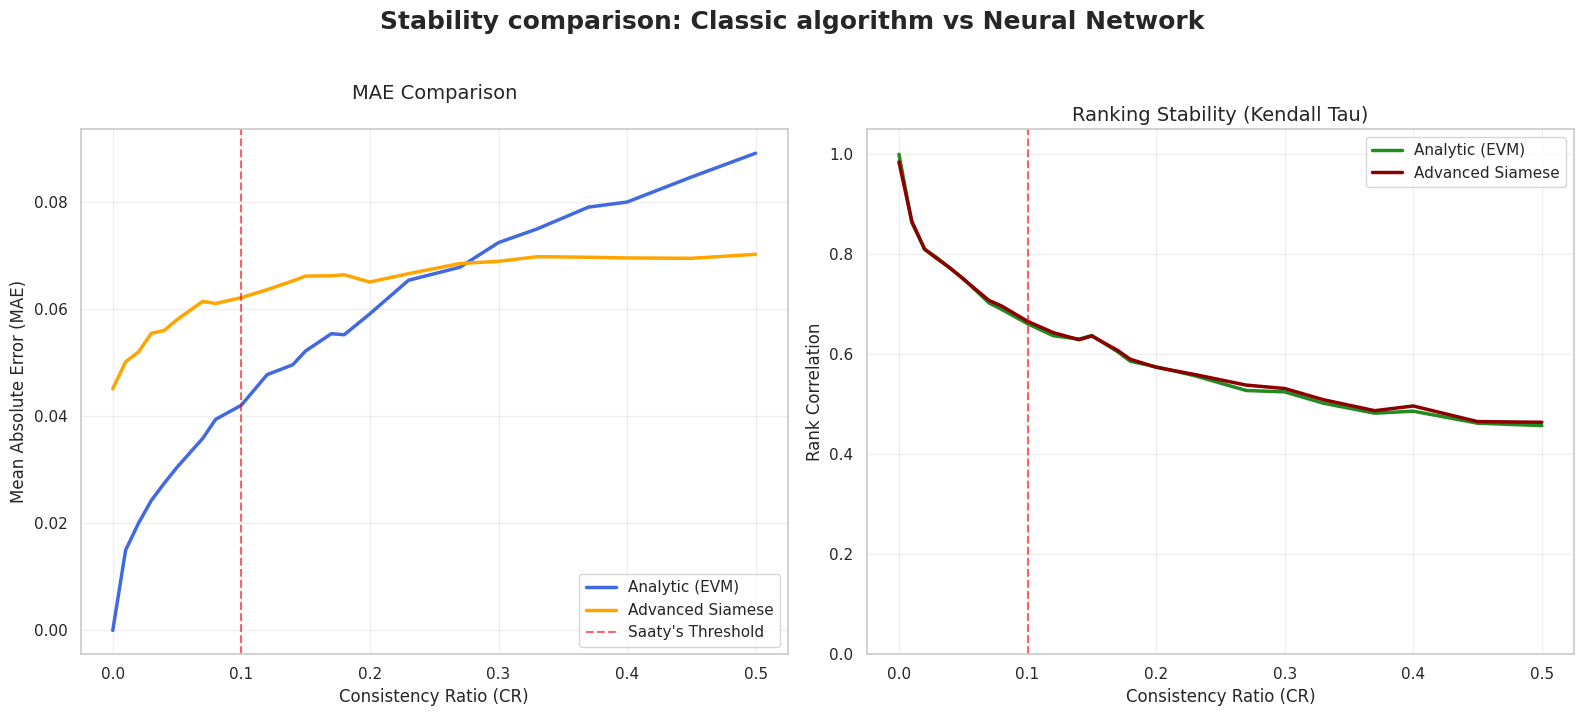

In [28]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5

MODEL_TYPE = "siamese"
LOSS_PARAM = f"cop{int(COP*100)}_rec{int(REC*100)}_stab{int(STAB*100)}_cons{int(CONS*100)}"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"


model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0429
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6411


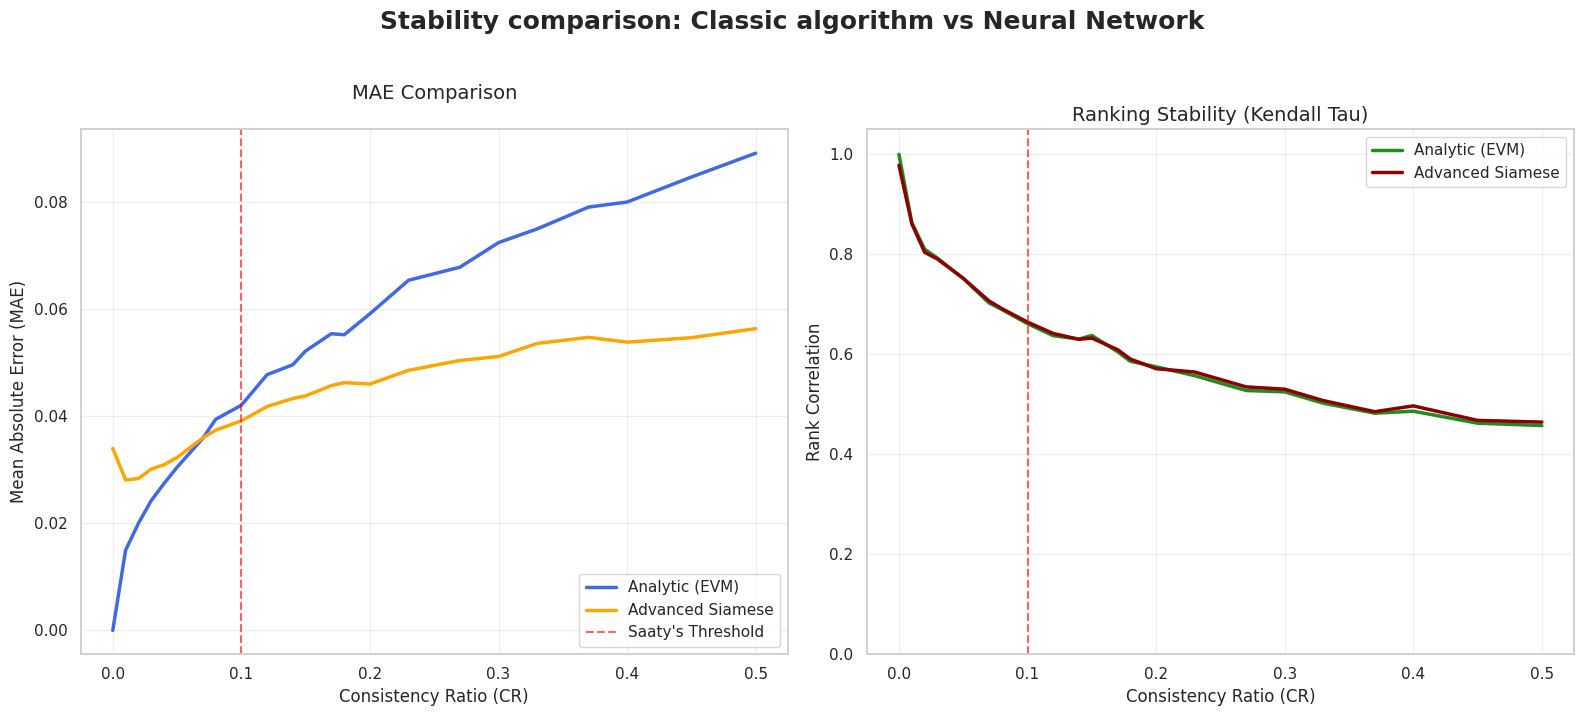

In [35]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508
Global mean Kendall correlation (EVM): 0.6398
----------------------------------------
Network: Siamese, Matrices COP
  -> Global mean MAE: 0.0476
  -> Global mean Kendall correlation: 0.6222
----------------------------------------
Network: Siamese, Weights COP
  -> Global mean MAE: 0.0429
  -> Global mean Kendall correlation: 0.6411
----------------------------------------


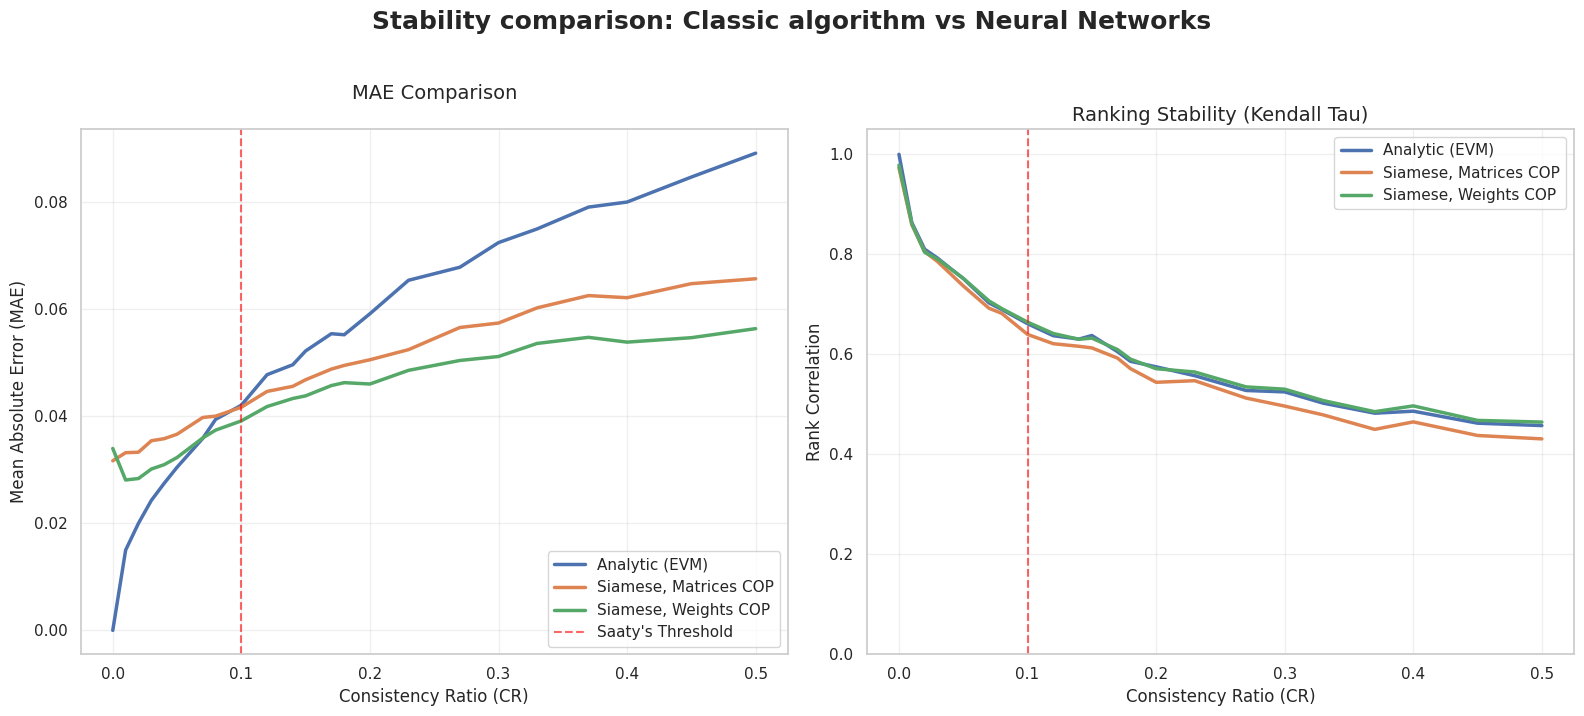

In [36]:
NN_weights_predictions["Siamese, Weights COP"] = predicted_priority_weights
compare_results_dict(evm_solver, evaluator, matrices, weights, NN_weights_predictions)

## Increasing training data quantity

In [ ]:
TRAIN_MATRICES_NUM = 20000
VALID_MATRICES_NUM = 2000
TEST_MATRICES_NUM = 2000
CRITERIA_NUM = 5
COP = 2
REC = 3
STAB = 0.1
CONS = 0.5

MODEL_TYPE = "siamese"
LOSS_PARAM = f"cop{int(COP*100)}_rec{int(REC*100)}_stab{int(STAB*100)}_cons{int(CONS*100)}"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"


model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, LOSS_PARAM, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = predict_batch_weights_siamese(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0507, NN: 0.0476
Global mean Kendall correlation (EVM): 0.6389, NN: 0.6191


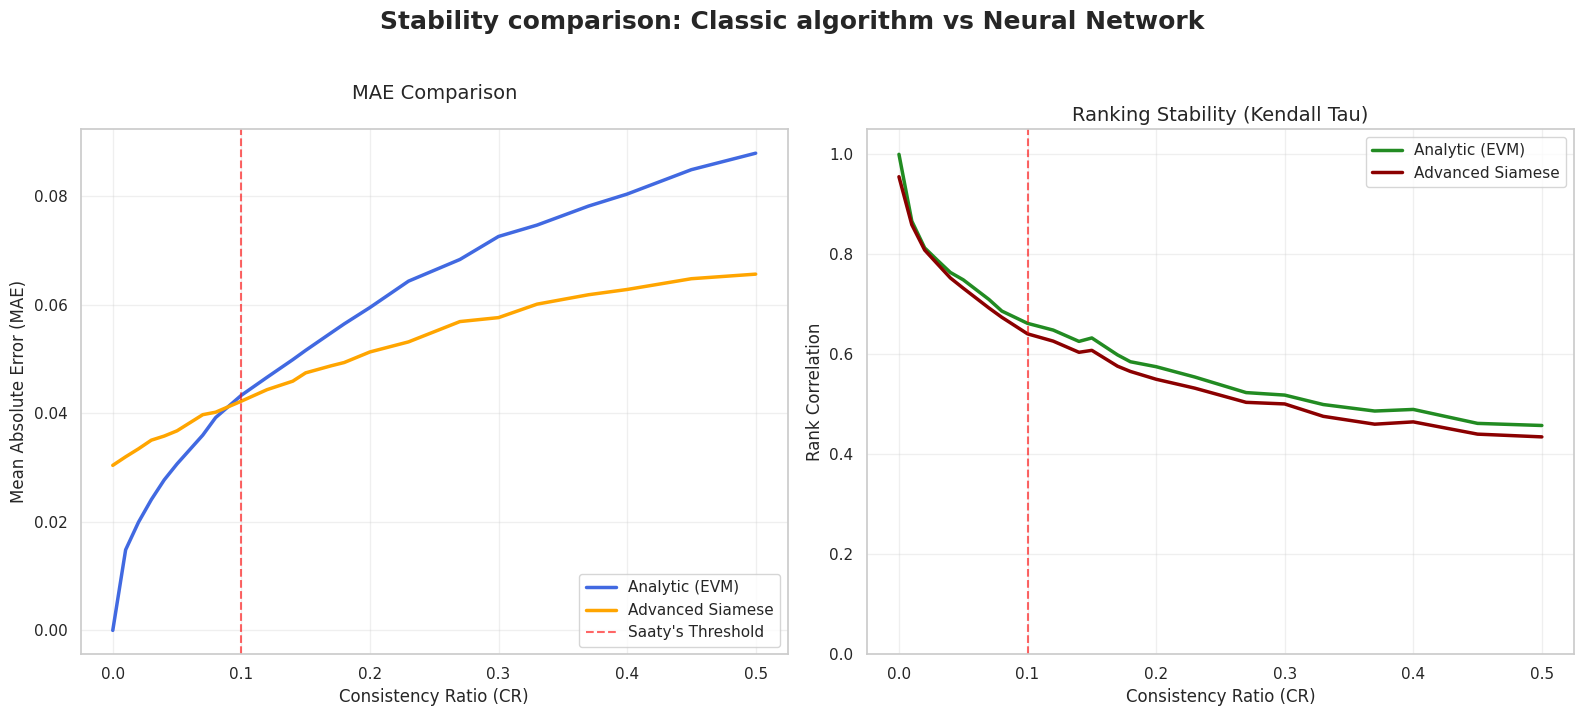

In [26]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

## Opposite Crs

In [ ]:
loader = MatricesLoader()
train_dataset = load_train_dataset_siamese_wtih_opposite_cr(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese_with_opposite_cr(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_opposite_crs"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

In [ ]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0479
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6201


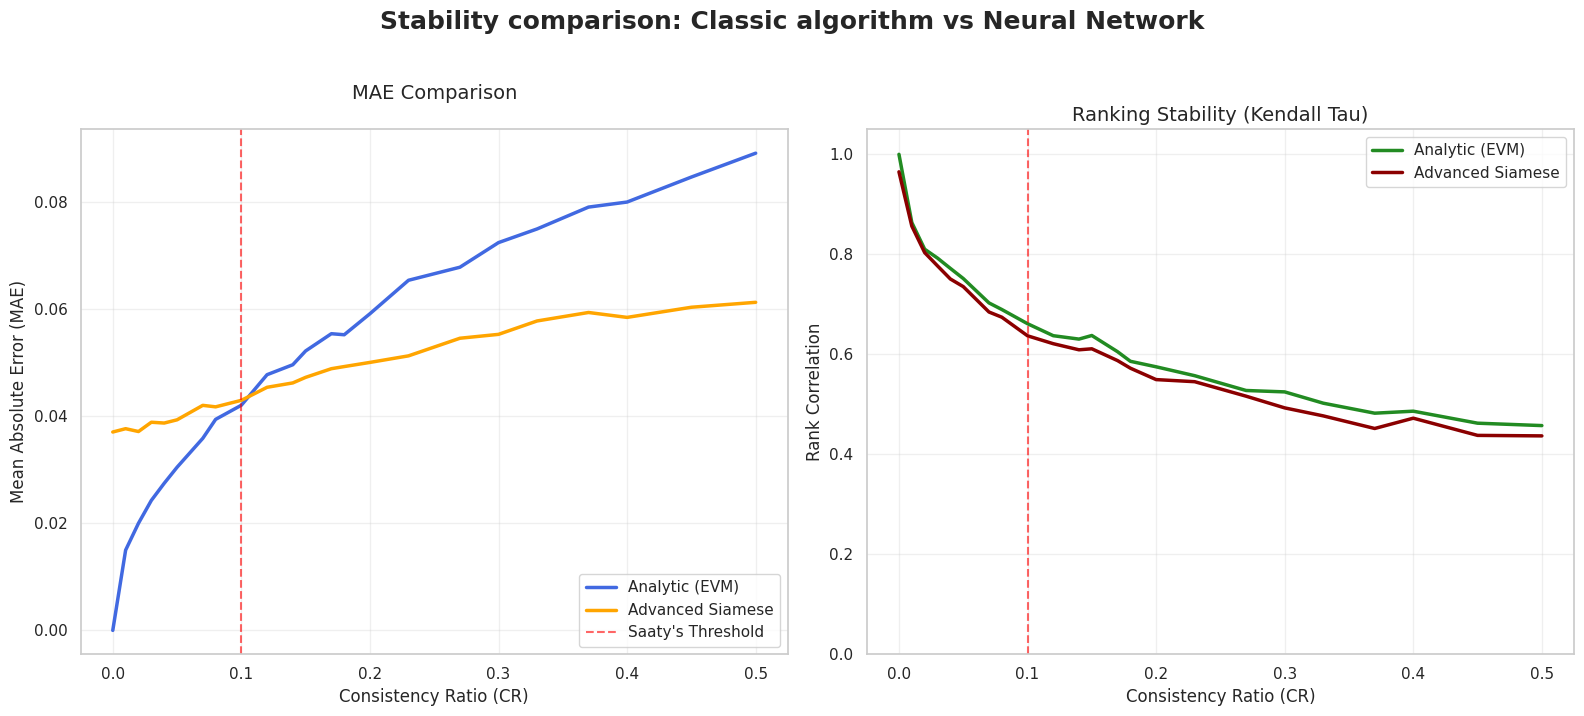

In [8]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Oposite CR - Wnioski

Założeniem eksperymentu "Opposite CR" było zmuszenie sieci syjamskiej do nauki idealnej, niewrażliwej na szum reprezentacji poprzez jednoczesne podawanie do jej dwóch gałęzi macierzy o skrajnie różnym poziomie spójności (np. $CR \approx 0.01$ oraz $CR \approx 0.50$), które odpowiadały tym samym docelowym wektorom priorytetów. 

Podejście to nie przyniosło jednak poprawy wyników. Jak wyraźnie widać na załączonych wykresach, wyniki stabilności rankingu dla sieci syjamskiej wyszły bardzo zbliżone do tych otrzymanych klasyczną metodą analityczną, a wręcz identyczną w porównaniu do bazowej metody wrzucania danych do gałęzi sieci.

Z matematycznego punktu widzenia, ten brak poprawy i zbieżność z klasycznym algorytmem wynika z następujących zjawisk:

#### 1. Regresja do algorytmu analitycznego
Zmuszenie sieci do jednoczesnej optymalizacji na podstawie dwóch skrajnych macierzy w jednym kroku wywołało potężny konflikt gradientów. Gałąź zaszumiona generowała gigantyczny błąd, zmuszając sieć do drastycznych korekt wag, które niszczyły precyzję wypracowaną przez gałąź z danymi czystymi.

#### 2. Utrata precyzji dla macierzy spójnych
Na wykresie błędów bezwzględnych widać wyraźnie, że dla macierzy idealnych ($CR < 0.05$) sieć syjamska radzi sobie znacznie gorzej niż EVM. Parowanie każdej czystej macierzy z jej skrajnie zaszumionym odpowiednikiem zadziałało jak zbyt agresywna regularyzacja. Sieć znieczuliła się na precyzyjne wartości, uśredniając swoje logity, co uniemożliwiło jej idealne odtworzenie bazowych wektorów priorytetów.

#### 3. Błędne założenie o przestrzeni reprezentacji
Architektury syjamskie świetnie radzą sobie z wyciąganiem cech niezmienniczych (*invariant features*), jeśli zestawione próbki różnią się drobnymi detalami (np. lekki szum na zdjęciu). Jednak w przypadku macierzy AHP, macierz idealna ($CR \approx 0.01$) i macierz w połowie losowa ($CR \approx 0.50$) reprezentują zupełnie inną topologię relacji logicznych.
Próba wymuszenia na modelu, aby zmapował ten całkowity chaos logiczny na ten sam wektor wagi co idealną spójność, okazała się dla sieci zadaniem nierozwiązywalnym przy użyciu samych warstw gęstych, skutkując brakiem przewagi nad klasycznym EVM.

## Siamese Neural Network

In [6]:
loader = MatricesLoader()
CRITERIA_NUM = 5
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 0.2
REC = 10
STAB = 2.5
CONS = 4
CRITERIA_NUM = 5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

In [ ]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0629
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6425


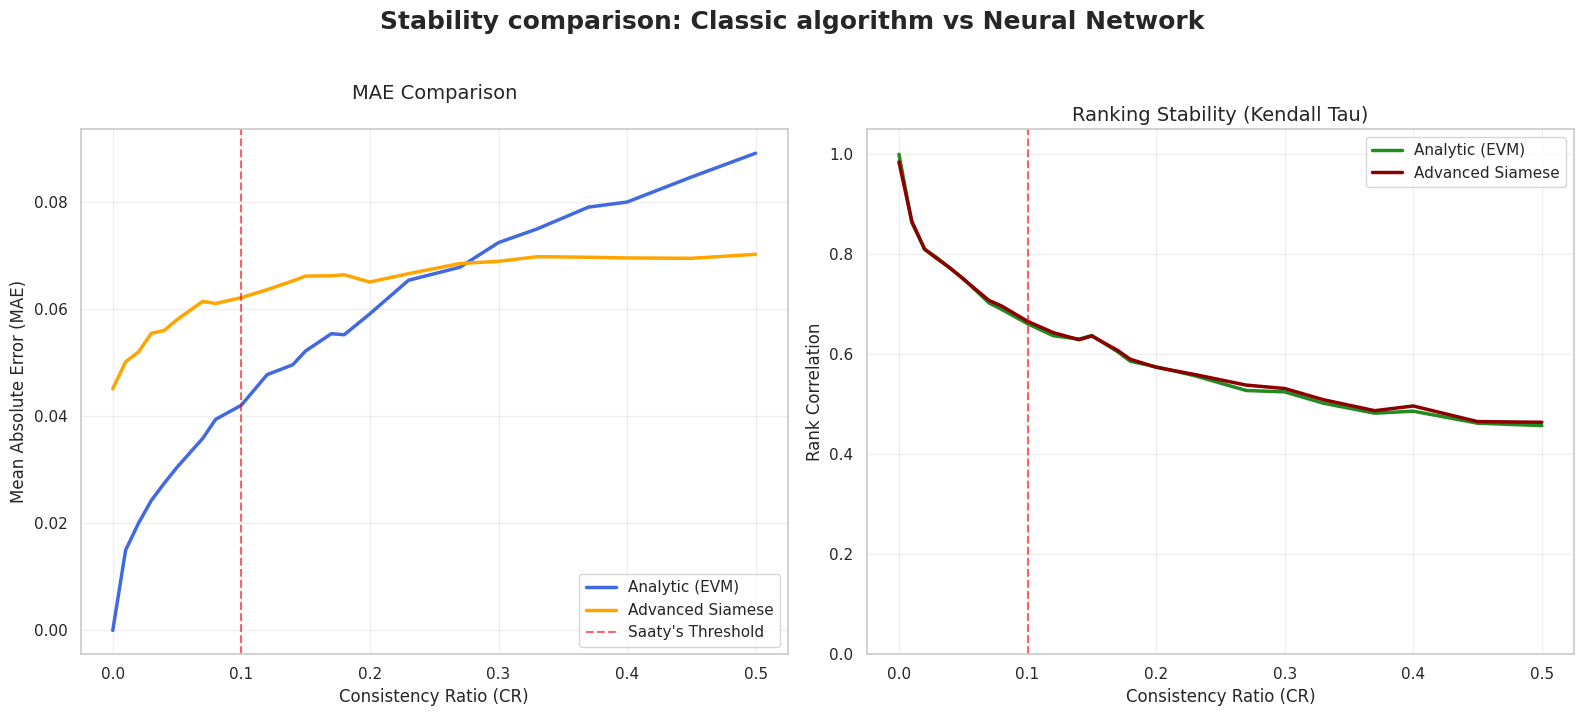

In [9]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

Analiza wykresów wyraźnie wskazuje, że obecna konfiguracja wag wielokryterialnej funkcji straty (COP = 0.2, REC = 10, STAB = 2.5, CONS = 4) jest nieodpowiednia i wprost hamuje potencjał sieci syjamskiej. Ze względu na drastyczną dominację członu rekonstrukcyjnego nad członem zachowania kolejności - COP, model podczas wstecznej propagacji błędu marginalizuje topologię rankingu, skupiając się niemal wyłącznie na dopasowywaniu odległości liczbowych. Silne wagi regularyzacyjne dla spójności i stabilności (CONS i STAB) ściągają wagi modelu w stronę bezpiecznego uśredniania, co tłumaczy bardzo wysoki, nienaturalny błąd bazowy dla macierzy idealnie spójnych. Aby sieć przestała być tylko drogim aproksymatorem EVM i zaczęła wygrywać w zadaniu poprawnego szeregowania kryteriów, należy radykalnie odwrócić te proporcje, drastycznie zwiększając wagę COP kosztem REC, zmuszając tym samym architekturę do priorytetyzowania bezwzględnej kolejności logitów nad ich idealną wartością punktową.

## Experiments with different number of criteria

### Criteria 3

In [9]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 3

loader = MatricesLoader()
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 3).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

FileNotFoundError: Files not found with consistency_ratio=0.3 in data/synthetic_data/noisy_cr/uniform/criteria3/train.

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 3
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

In [ ]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

In [ ]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Criteria 5

In [5]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 5

loader = MatricesLoader()
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [6]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.268699 | Valid Loss: 0.266237 | Valid MAE: 0.0431
Epoch number [20/500] | Train Loss: 0.267584 | Valid Loss: 0.265605 | Valid MAE: 0.0430
Epoch number [30/500] | Train Loss: 0.267016 | Valid Loss: 0.265043 | Valid MAE: 0.0431
Epoch number 33: Learning Rate was reduced to 0.000250
Epoch number 40: Learning Rate was reduced to 0.000125
Epoch number [40/500] | Train Loss: 0.266110 | Valid Loss: 0.264955 | Valid MAE: 0.0431
Epoch number 46: Learning Rate was reduced to 0.000063

EARLY STOPPING in epoch 49.
Wages are restored to the best valid loss: 0.264474
History and model: advanced_10000m_5crit_COP_optimized was saved in models/siamese/cop100_rec200_stab20_cons50


In [7]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0429
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6411


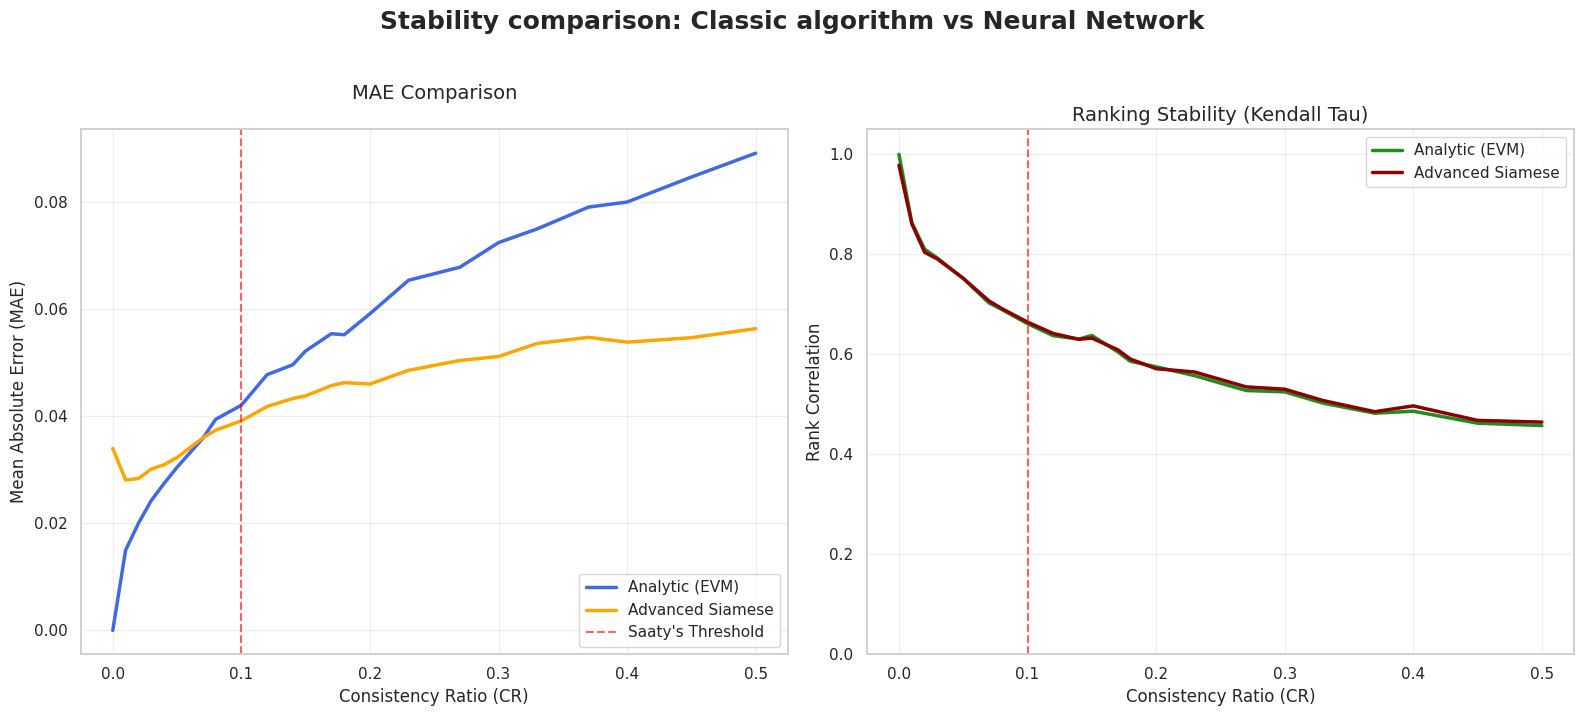

In [8]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Criteria 7

In [14]:
loader = MatricesLoader()
CRITERIA_NUM = 7
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 7
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.244307 | Valid Loss: 0.239541 | Valid MAE: 0.0272
Epoch number [20/500] | Train Loss: 0.242116 | Valid Loss: 0.238321 | Valid MAE: 0.0273
Epoch number [30/500] | Train Loss: 0.241122 | Valid Loss: 0.237814 | Valid MAE: 0.0274
Epoch number 40: Learning Rate was reduced to 0.000250
Epoch number [40/500] | Train Loss: 0.240462 | Valid Loss: 0.238040 | Valid MAE: 0.0274
Epoch number [50/500] | Train Loss: 0.239441 | Valid Loss: 0.237798 | Valid MAE: 0.0275
Epoch number 52: Learning Rate was reduced to 0.000125
Epoch number 58: Learning Rate was reduced to 0.000063
Epoch number [60/500] | Train Loss: 0.238639 | Valid Loss: 0.237705 | Valid MAE: 0.0274

EARLY STOPPING in epoch 61.
Wages are restored to the best valid loss: 0.237509
History and model: advanced_10000m_7crit_COP_optimized was saved in models/siamese/cop100_rec200_stab20_cons50


In [16]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 7).
Succ

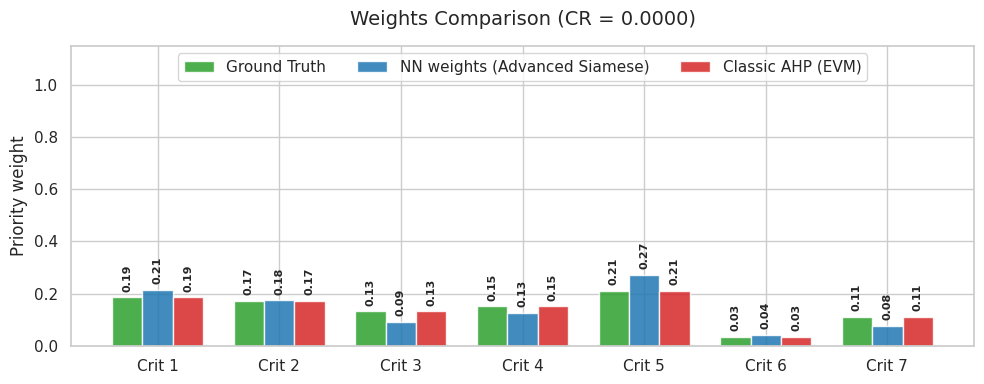

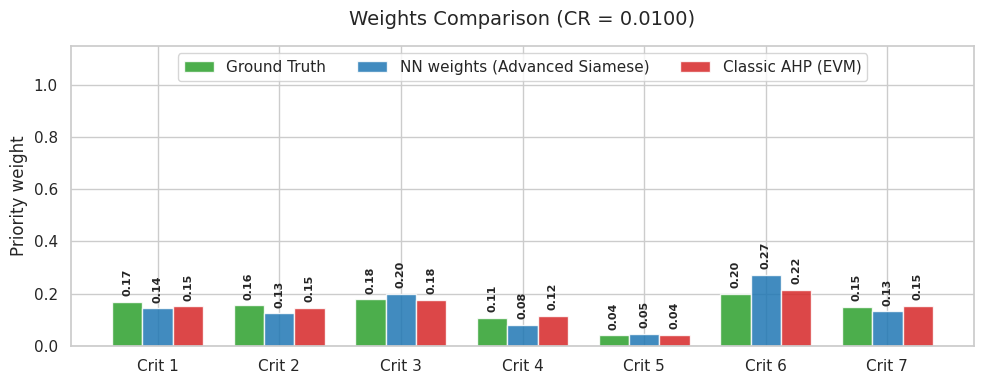

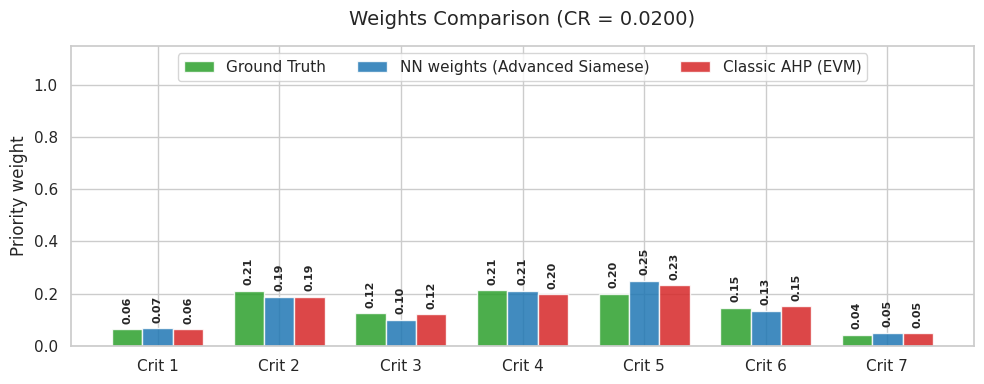

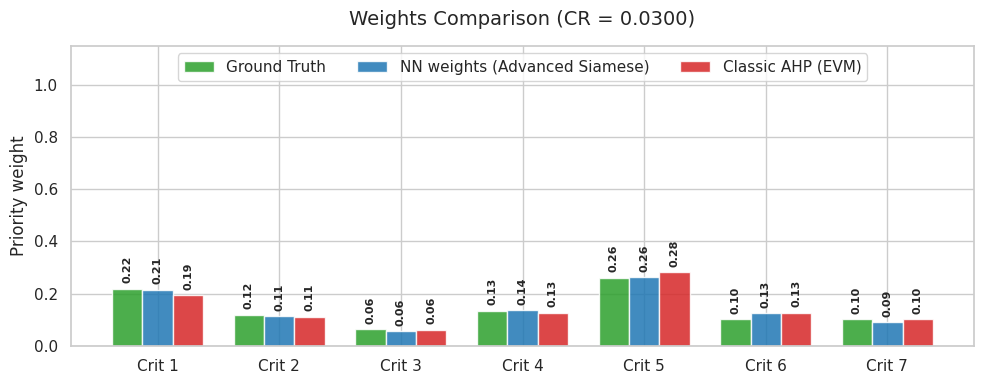

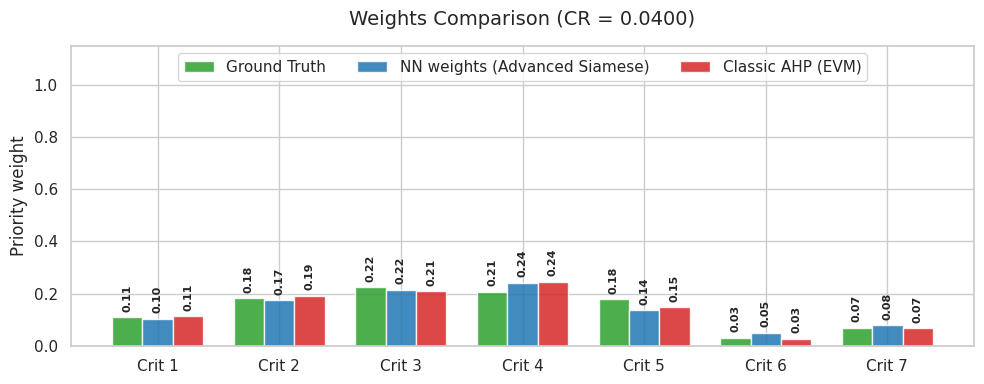

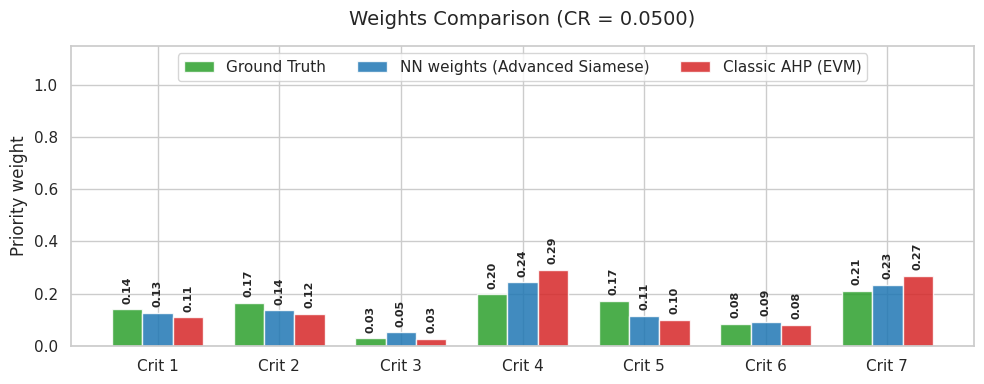

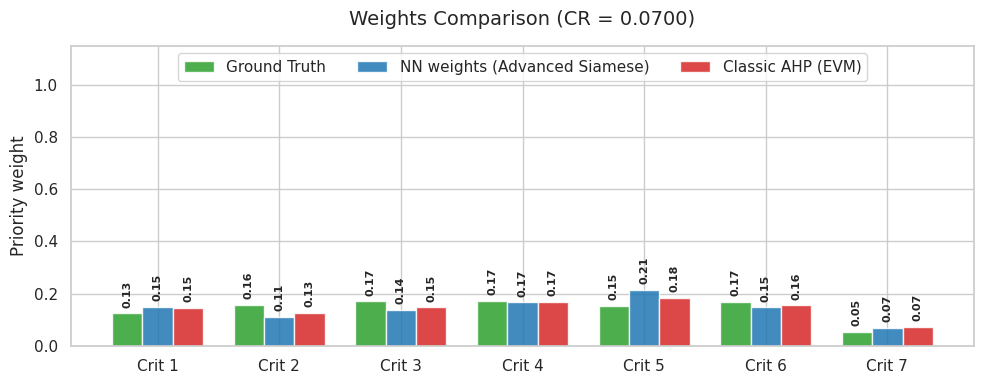

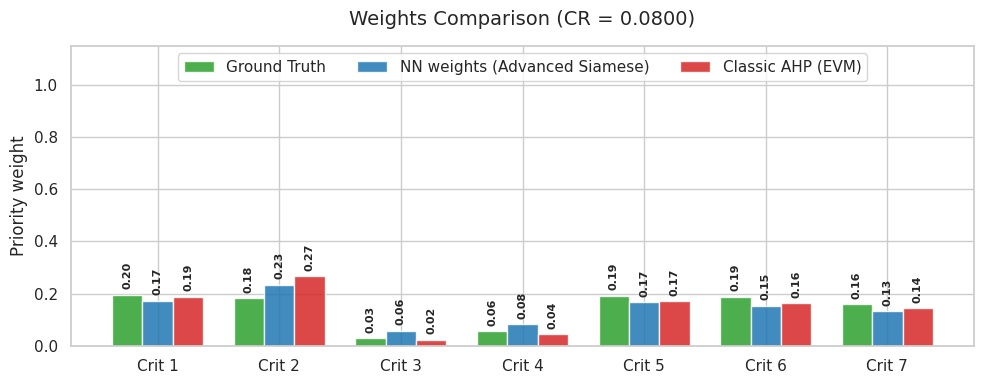

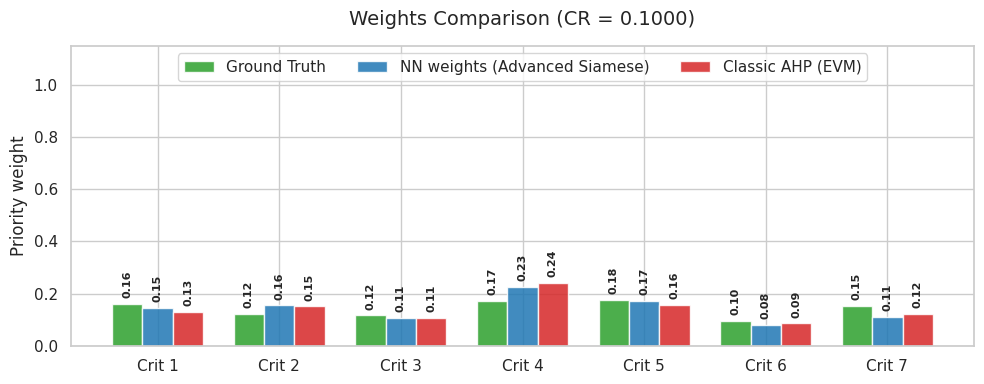

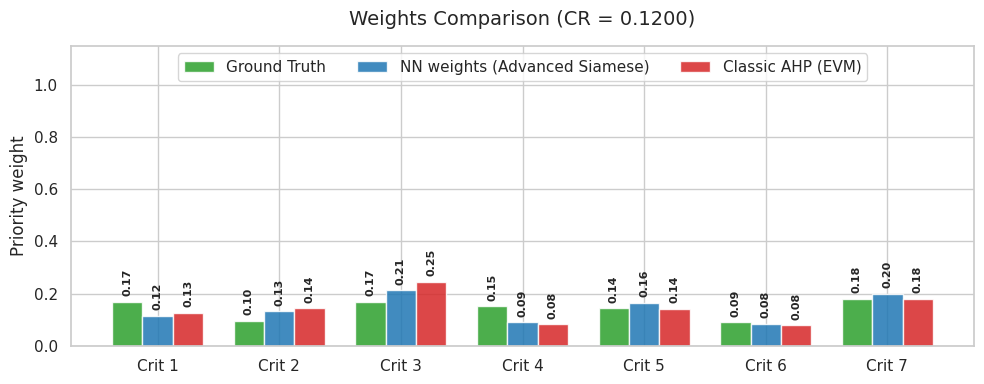

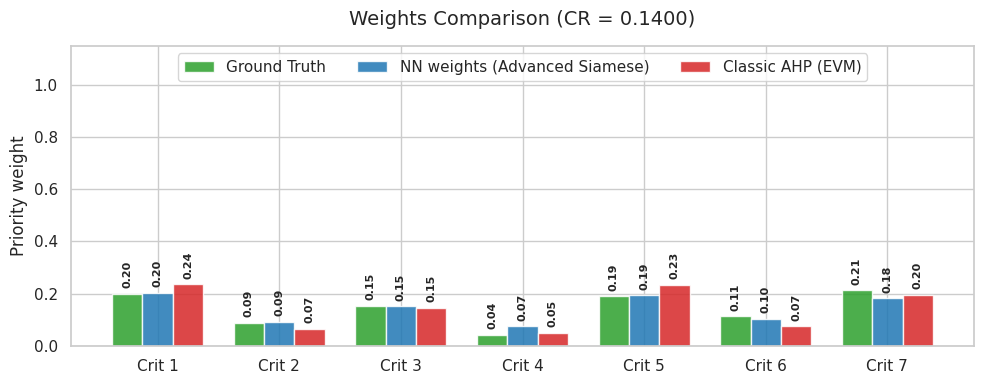

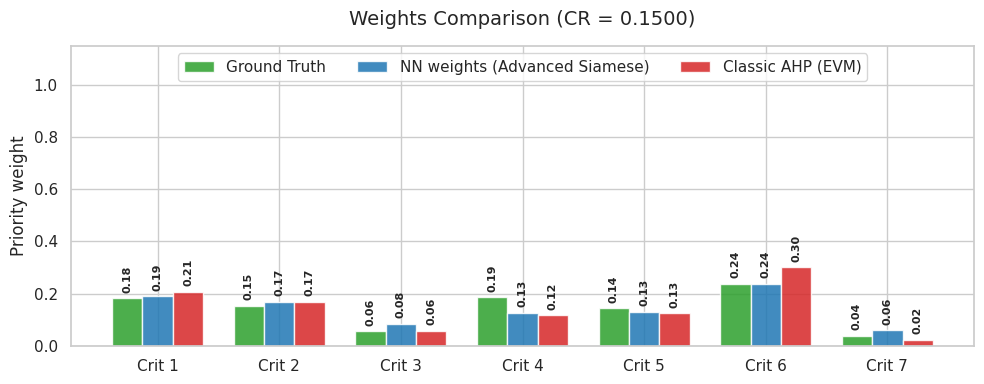

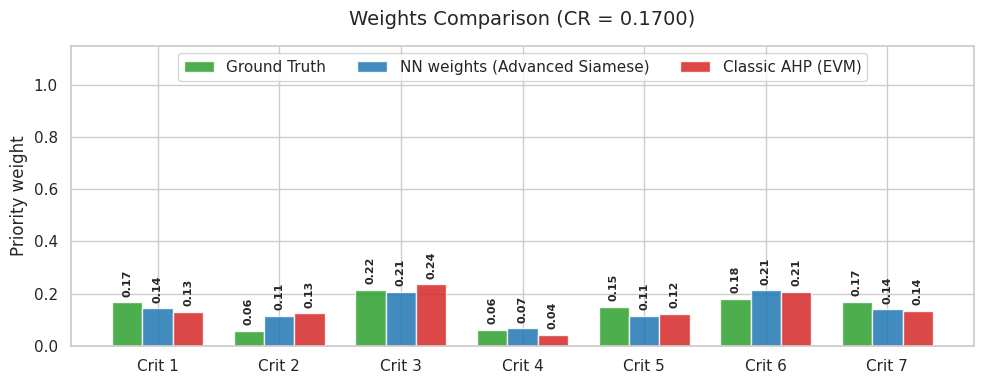

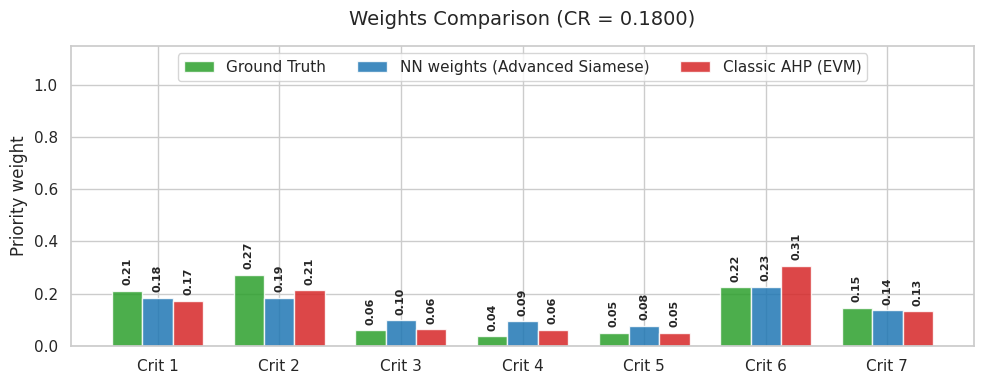

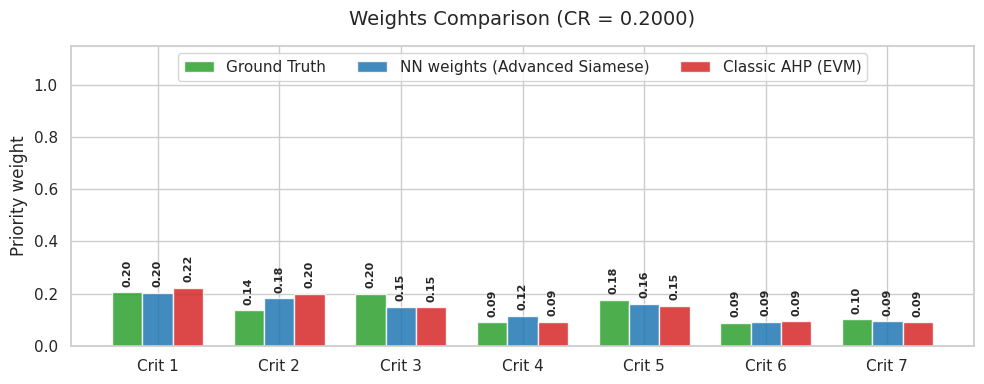

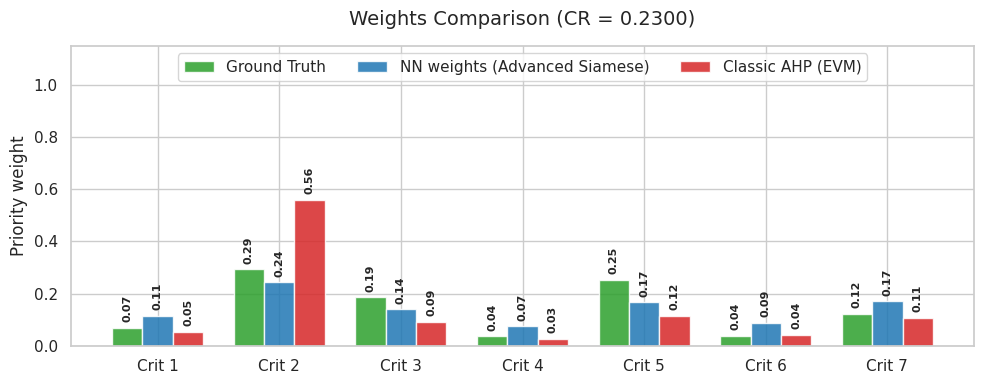

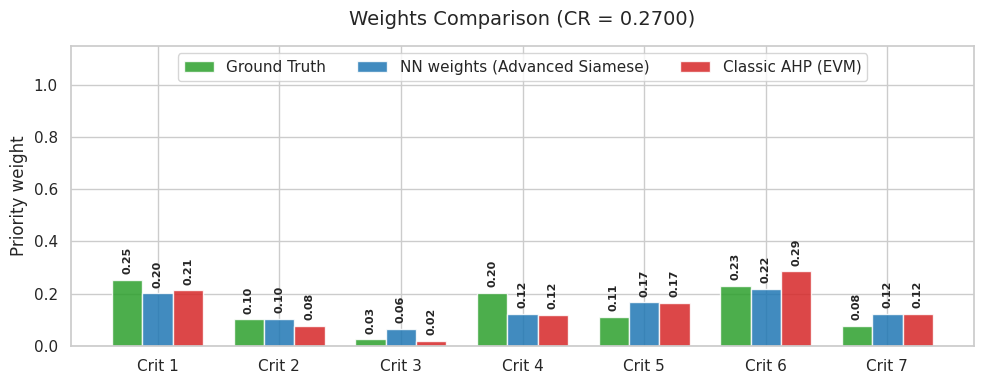

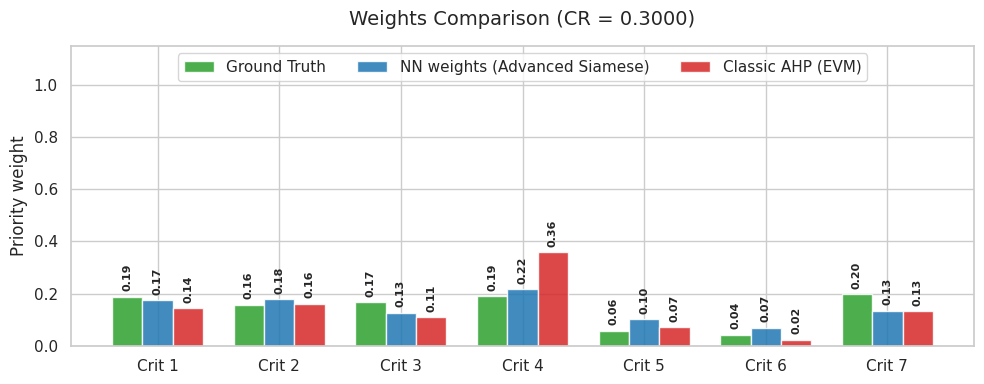

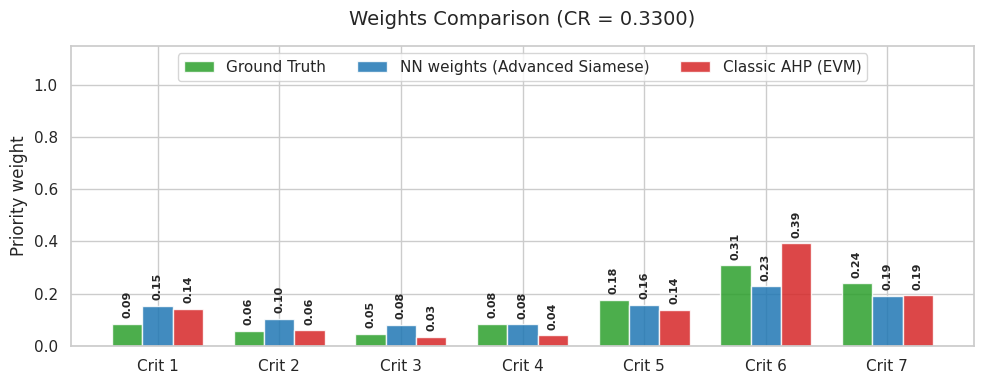

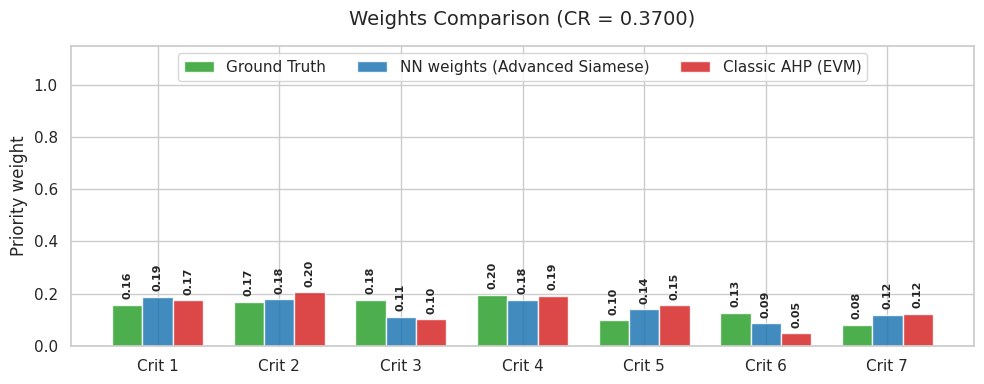

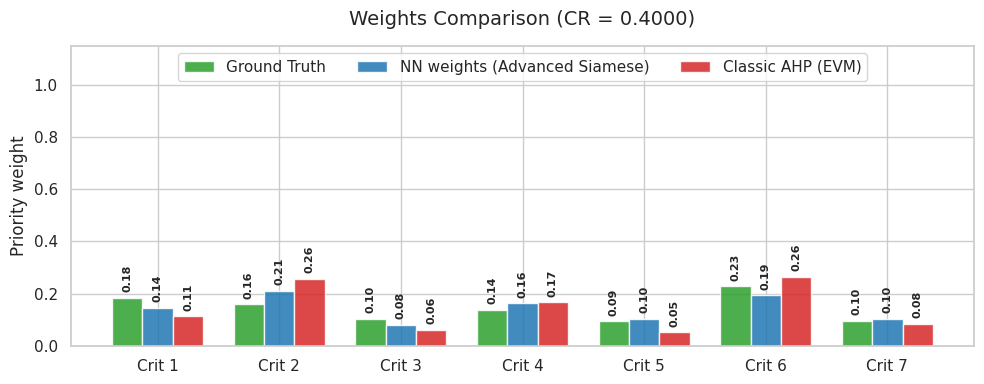

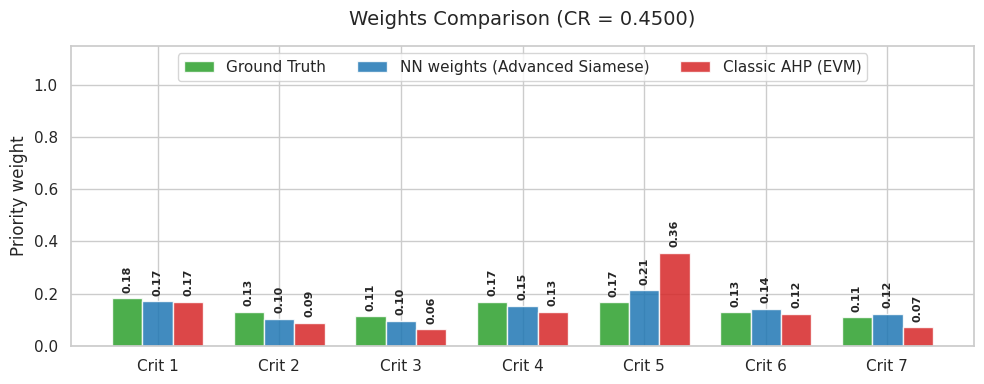

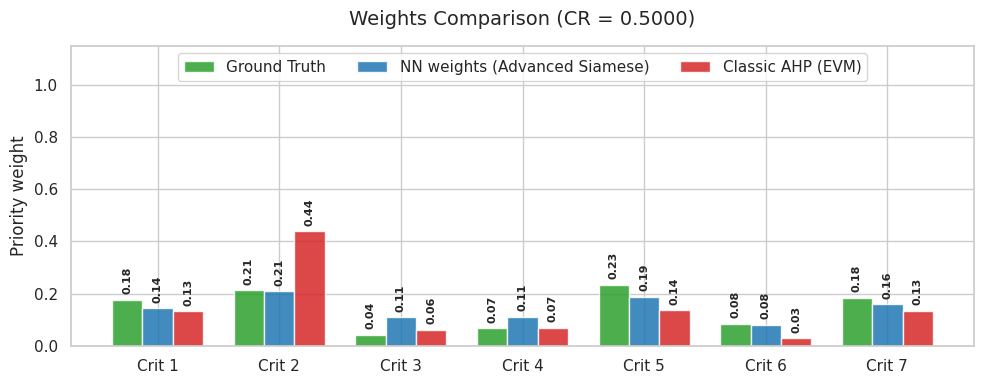

In [17]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0302, NN: 0.0273
Global mean Kendall correlation (EVM): 0.6956, NN: 0.7028


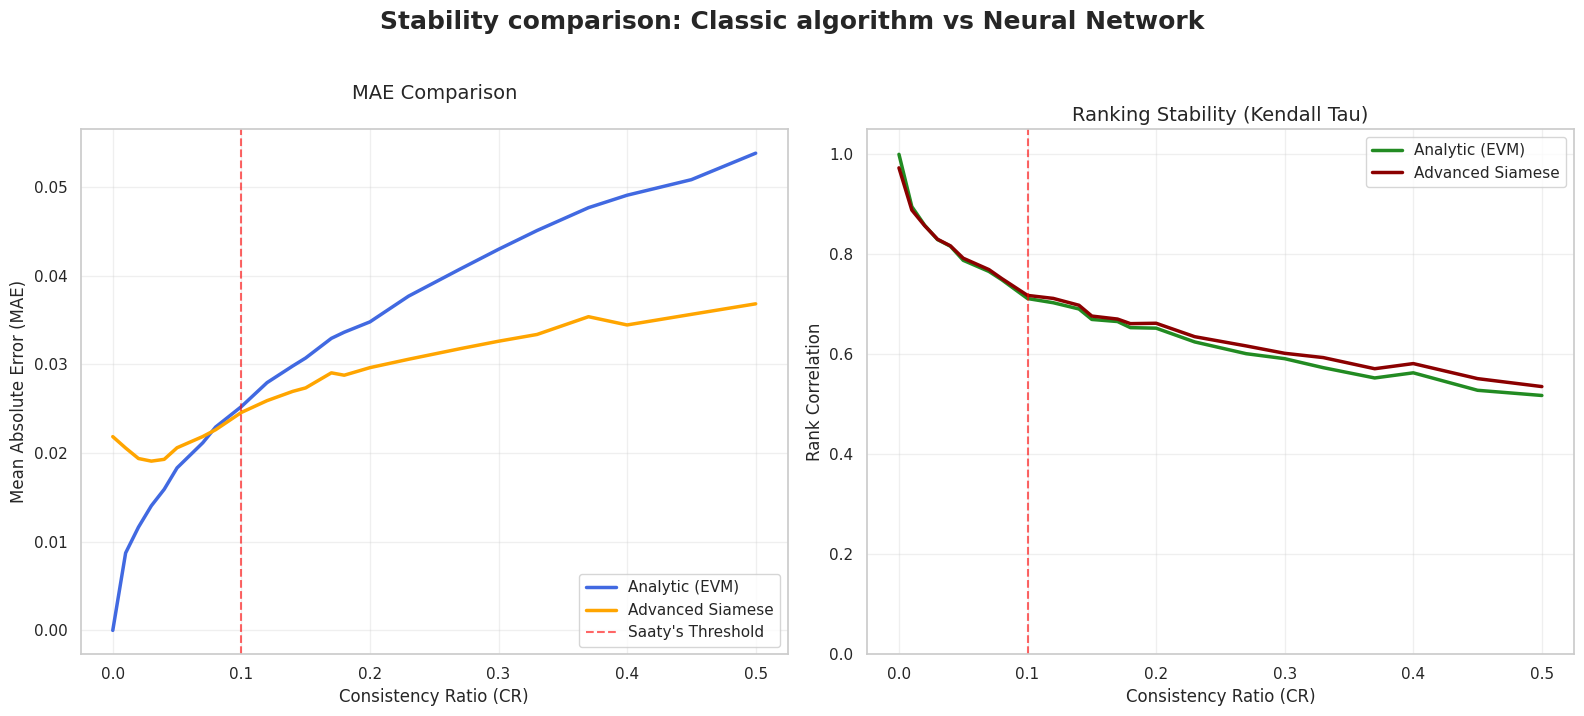

In [18]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Criteria 9

In [20]:
loader = MatricesLoader()
CRITERIA_NUM = 9
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 20000 noised matrices (level: cr000, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr001, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr002, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr003, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr004, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr005, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr007, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr008, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr010, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr012, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr014, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 9
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.231053 | Valid Loss: 0.224585 | Valid MAE: 0.0194
Epoch number [20/500] | Train Loss: 0.229035 | Valid Loss: 0.223207 | Valid MAE: 0.0194
Epoch number [30/500] | Train Loss: 0.228292 | Valid Loss: 0.222658 | Valid MAE: 0.0195
Epoch number [40/500] | Train Loss: 0.227854 | Valid Loss: 0.222606 | Valid MAE: 0.0196
Epoch number 44: Learning Rate was reduced to 0.000250
Epoch number [50/500] | Train Loss: 0.227307 | Valid Loss: 0.222125 | Valid MAE: 0.0196
Epoch number 52: Learning Rate was reduced to 0.000125
Epoch number 60: Learning Rate was reduced to 0.000063
Epoch number [60/500] | Train Loss: 0.226988 | Valid Loss: 0.221979 | Valid MAE: 0.0196
Epoch number 68: Learning Rate was reduced to 0.000031
Epoch number [70/500] | Train Loss: 0.226817 | Valid Loss: 0.221899 | Valid MAE: 0.0196
Epoch number 75: Learning Rate was reduced to 0.000016
Epoch number [80/500] | Train Loss: 0.226756 | Valid Loss: 0.221904 | Valid MAE: 0.0196
Epoch number 81: Lear

In [22]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 2000 noised matrices (level: cr000, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr001, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr002, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr003, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr004, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr005, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr007, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr008, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr010, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr012, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr014, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr015, number of criterias: 9).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0211, NN: 0.0196
Global mean Kendall correlation (EVM): 0.7246, NN: 0.7362


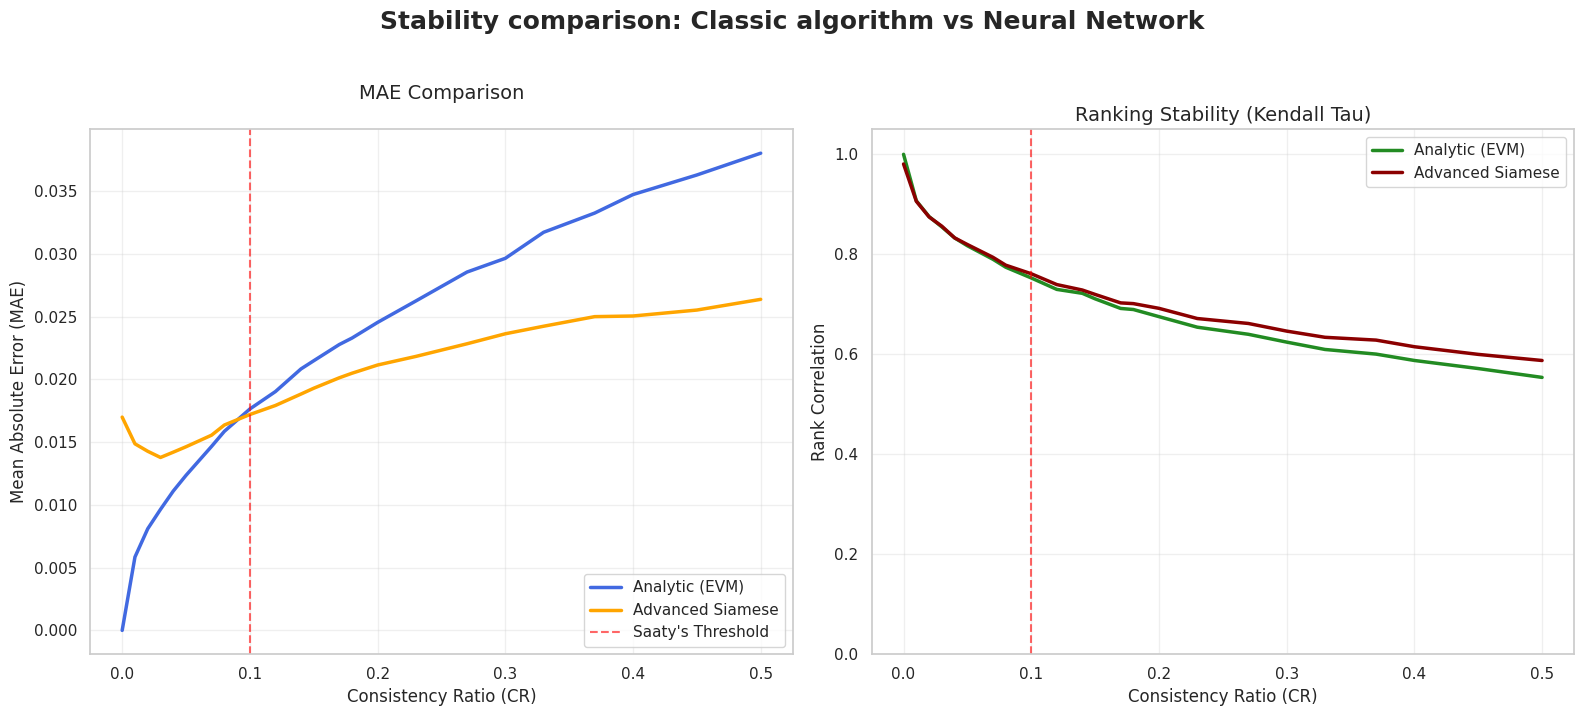

In [23]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)